<a href="https://colab.research.google.com/github/Atharv-Chopade/Deep-Learning/blob/main/DL_Day_10_P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project 1: ANN

Dataset: Wine or Breast Cancer

Compare ReLU vs Tanh

Compare Adam vs SGD




In [1]:
from sklearn.datasets import load_breast_cancer , load_wine
data1 = load_breast_cancer()
data2 = load_wine()

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
activation = ['relu' , 'tanh']
optimizer = ['adam' , 'sgd']

In [4]:
results_breast_cancer = {
    'activation' : [],
    'optimizer' : [],
    'accuracy' : [],
    'loss' : []
}
results_wine = {
    'activation' : [],
    'optimizer' : [],
    'accuracy' : [],
    'loss' : []
}

In [5]:
from sklearn.model_selection import train_test_split
X1_train , X1_test , y1_train , y1_test = train_test_split(data1.data , data1.target , test_size = 0.2)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X1_train = scaler.fit_transform(X1_train)
X1_test = scaler.transform(X1_test)

In [7]:
for a in activation:
   for o in optimizer:
     model = Sequential()
     model.add(Dense(128 , activation = a))
     model.add(Dense(64 , activation = a))
     model.add(Dense(32 , activation = a))
     model.add(Dense(16 , activation = a))
     model.add(Dense(1 , activation = 'sigmoid'))

     model.compile(loss = 'binary_crossentropy' , optimizer = o , metrics = ['accuracy'])

     model.fit(X1_train , y1_train , epochs = 100 , verbose = 0)

     loss , accuracy = model.evaluate(X1_test , y1_test)

     results_breast_cancer['activation'].append(a)
     results_breast_cancer['optimizer'].append(o)
     results_breast_cancer['accuracy'].append(accuracy)
     results_breast_cancer['loss'].append(loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9649 - loss: 0.1569  
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9649 - loss: 0.0788 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9737 - loss: 0.1561 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9649 - loss: 0.0971  


In [8]:
X2_train , X2_test , y2_train , y2_test = train_test_split(data2.data , data2.target , test_size = 0.2)
X2_train = scaler.fit_transform(X2_train)
X2_test = scaler.transform(X2_test)

In [9]:
for a in activation:
    for o in optimizer:

        model = Sequential()
        model.add(Dense(128, activation=a))
        model.add(Dense(64, activation=a))
        model.add(Dense(32, activation=a))
        model.add(Dense(16, activation=a))
        model.add(Dense(3, activation='softmax'))

        model.compile(optimizer=o,loss='sparse_categorical_crossentropy',metrics=['accuracy'] )

        model.fit(X2_train,y2_train,epochs=100,verbose=0)

        loss, accuracy = model.evaluate(X2_test, y2_test, verbose=0)

        results_wine['activation'].append(a)
        results_wine['optimizer'].append(o)
        results_wine['accuracy'].append(accuracy)
        results_wine['loss'].append(loss)

In [10]:
import pandas as pd
results = {
    'breast_cancer' : pd.DataFrame(results_breast_cancer) ,
    'wine' : pd.DataFrame(results_wine)
}

In [11]:
results = pd.concat(results)

In [12]:
results

activation optimizer  accuracy      loss
breast_cancer 0       relu      adam  0.964912  0.156890
              1       relu       sgd  0.964912  0.078822
              2       tanh      adam  0.973684  0.156112
              3       tanh       sgd  0.964912  0.097123
wine          0       relu      adam  0.972222  0.135745
              1       relu       sgd  0.944444  0.106263
              2       tanh      adam  0.972222  0.076544
              3       tanh       sgd  0.972222  0.083997

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = results.reset_index()

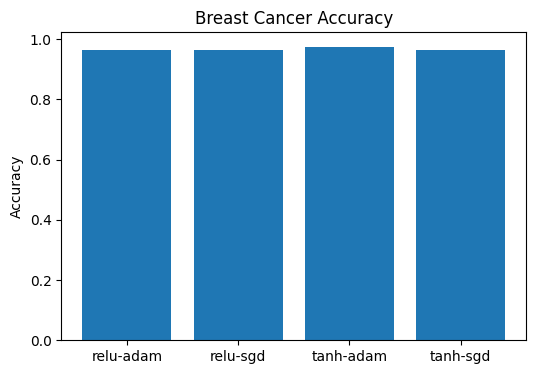

In [19]:
breast = df[df['level_0']=='breast_cancer']

plt.figure(figsize=(6,4))

plt.bar(
    breast['activation'] + "-" + breast['optimizer'],
    breast['accuracy']
)

plt.title("Breast Cancer Accuracy")
plt.ylabel("Accuracy")
plt.show()

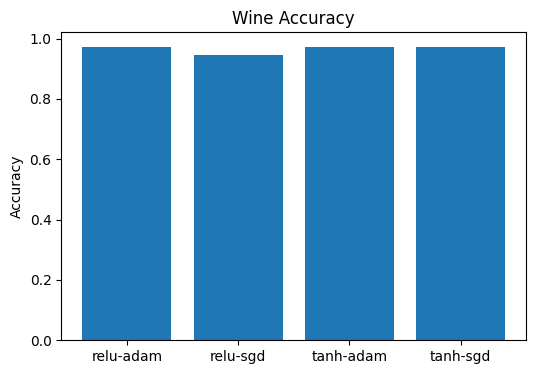

In [22]:
wine = df[df['level_0']=='wine']

plt.figure(figsize=(6,4))

plt.bar(
    wine['activation'] + "-" + wine['optimizer'],
    wine['accuracy']
)

plt.title("Wine Accuracy")
plt.ylabel("Accuracy")
plt.show()

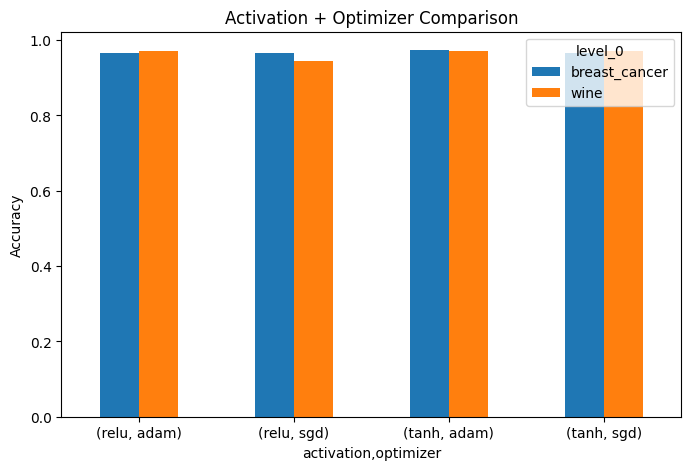

In [24]:
pivot = df.pivot_table(
    index=['activation','optimizer'],
    columns='level_0',
    values='accuracy'
)

pivot.plot(
    kind='bar',
    figsize=(8,5)
)

plt.ylabel("Accuracy")
plt.title("Activation + Optimizer Comparison")
plt.xticks(rotation=0)
plt.show()